# Exploratory Data Analysis of the ArtEmis Dataset

This notebook presents an exploratory data analysis (EDA) of the **ArtEmis** dataset, a large-scale multimodal dataset bridging visual art, emotion labels, and human textual explanations.

### Goals of this analysis:
- **Understand** the dataset structure and file organization.
- **Inspect** data quality, missing values, and duplicates.
- **Visualize** distributions of emotions, art styles, and text properties.
- **Identify** insights into human emotional agreement and diversity across different artworks.

##### **Dataset Source:** [Kaggle - ArtEmis Dataset](http://kaggle.com/datasets/rollas/artemis-dataset-including-10k-images)
---

## 1. Import Libraries
In this section, we import the libraries used for data dependency, high-level visualization, and image processing. We use **Plotly** for interactive charts and **Matplotlib** for image grids.

In [ ]:
!pip install kagglehub pandas matplotlib seaborn pillow plotly -q

import os
from pathlib import Path
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from PIL import Image
import kagglehub

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset
We use `kagglehub` to download the dataset. Then, we inspect the folder structure to locate the metadata and images.

In [ ]:
# Download dataset
base_path = Path(kagglehub.dataset_download("rollas/artemis-dataset-including-10k-images"))
print(f"Dataset downloaded to: {base_path}")

# Inspect folder structure
for root, dirs, files in os.walk(base_path):
    level = root.replace(str(base_path), '').count(os.sep)
    indent = ' ' * 4 * (level)
    if level < 2: # Limit depth for printing
        print(f"{indent}{os.path.basename(root)}/ -> {len(files)} files")

# Identify CSV file
csv_files = list(base_path.rglob("*.csv"))
df = pd.read_csv(csv_files[0])
print(f"\nSuccessfully loaded: {csv_files[0].name}")

Using Colab cache for faster access to the 'artemis-dataset-including-10k-images' dataset.
Dataset downloaded to: /kaggle/input/artemis-dataset-including-10k-images
artemis-dataset-including-10k-images/ -> 1 files
    images/ -> 49062 files

Successfully loaded: dataset_final.csv


## 3. Dataset Overview
A first look at the dataset size, column names, and sample records.

In [ ]:
!ls -la /root/.cache/kagglehub/datasets/rollas/artemis-dataset-including-10k-images/versions/4

ls: cannot access '/root/.cache/kagglehub/datasets/rollas/artemis-dataset-including-10k-images/versions/4': No such file or directory


In [ ]:
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
display(df.info())
display(df.head())

Dataset shape: (49056, 8)

Columns: ['emotion', 'utterance', 'art_style', 'painting', 'anchor_art_style', 'anchor_painting', 'repetition', 'filename']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49056 entries, 0 to 49055
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   emotion           49056 non-null  object
 1   utterance         49056 non-null  object
 2   art_style         49056 non-null  object
 3   painting          49056 non-null  object
 4   anchor_art_style  49056 non-null  object
 5   anchor_painting   49056 non-null  object
 6   repetition        49056 non-null  int64 
 7   filename          49056 non-null  object
dtypes: int64(1), object(7)
memory usage: 3.0+ MB


None

,emotion,utterance,art_style,painting,anchor_art_style,anchor_painting,repetition,filename
0,sadness,This painting shows a gloomy day. The darkness...,Realism,johan-hendrik-weissenbruch_windy-day,Realism,johan-hendrik-weissenbruch_ship-canal,1,johan-hendrik-weissenbruch_windy-day.jpg
1,sadness,the weather and atmosphere makes me feel sad,Romanticism,ivan-aivazovsky_landscape-with-a-schooner-1880,Realism,johan-hendrik-weissenbruch_ship-canal,45,ivan-aivazovsky_landscape-with-a-schooner-1880...
2,sadness,"Dark and moody, cloudy sky that is depressing",Impressionism,paul-gauguin_clearing-1873,Realism,johan-hendrik-weissenbruch_ship-canal,18,paul-gauguin_clearing-1873.jpg
3,sadness,the picture is dark with a somber tone,Impressionism,john-henry-twachtman_winter-landscape,Realism,johan-hendrik-weissenbruch_ships-in-harbour,7,john-henry-twachtman_winter-landscape.jpg
4,sadness,the dark colors make the painting look gloomy,Impressionism,eugene-boudin_trouville-the-port-1864,Realism,johan-hendrik-weissenbruch_ships-in-harbour,5,eugene-boudin_trouville-the-port-1864.jpg


## 4. Missing Values Analysis
We identify whether the dataset contains incomplete records. Cleaning missing values is crucial for robust multimodal modeling.

In [ ]:
missing = df.isnull().sum().reset_index()
missing.columns = ["column", "missing_count"]
missing = missing[missing["missing_count"] > 0].sort_values("missing_count", ascending=False)

if not missing.empty:
    fig = px.bar(missing, x="column", y="missing_count",
                 title="Missing Values by Column", text="missing_count",
                 color_discrete_sequence=['#EF553B'])
    fig.update_layout(xaxis_title="Column", yaxis_title="Missing Count", template="plotly_white")
    fig.show()
else:
    print("No missing values detected. Great!")

No missing values detected. Great!


**Observation:** Knowing which columns contain missing values helps determine whether to drop rows or apply imputation strategies.

## 5. Duplicate Analysis
Duplicate records can introduce bias during training and evaluation.

In [ ]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count} ({ (duplicate_count/len(df))*100 :.2f}%)")

Number of duplicate rows: 0 (0.00%)


**Observation:** Minimal duplicates suggest high-quality data collection. If high, they should be removed before modeling.

## 6. Emotion Label Distribution
ArtEmis is centered around emotions. We visualize the distribution to check for class imbalance.

In [ ]:
emotion_col = "emotion"
emotion_counts = df[emotion_col].value_counts().reset_index()
emotion_counts.columns = ["emotion", "count"]

fig = px.bar(emotion_counts, x="emotion", y="count",
             title="Distribution of Emotion Labels", text="count",
             color="count", color_continuous_scale='Viridis')
fig.update_layout(xaxis_title="Emotion", yaxis_title="Count", template="plotly_white")
fig.show()

**Observation:** Strong imbalances (e.g., more 'contentment' than 'disgust') may require weighted loss functions or oversampling during training.

## 7. Text Length Analysis
We analyze the textual descriptions (utterances) to see how detailed the annotators were.

In [ ]:
text_col = "utterance"
df["text_length_words"] = df[text_col].astype(str).apply(lambda x: len(x.split()))

fig = px.histogram(df, x="text_length_words", nbins=50,
                   title="Distribution of Text Length (Words)",
                   color_discrete_sequence=['#636EFA'])
fig.update_layout(xaxis_title="Number of Words", yaxis_title="Frequency", template="plotly_white")
fig.show()

**Observation:** Most captions are concise. This information helps in setting the maximum sequence length for NLP models.

The distribution of text length shows that most utterances are relatively short, typically ranging between 5 and 20 words. This suggests that annotators tend to provide concise emotional descriptions rather than long narratives.

However, a small number of outliers contain significantly longer descriptions (up to 150 words), which may introduce variability and noise. These long utterances may require preprocessing such as truncation or normalization before modeling.

## 8. Genre / Style Distribution
Visualizing the top artistic categories represented in the dataset.

In [ ]:
for col in ["genre", "art_style"]:
    if col in df.columns:
        counts = df[col].value_counts().reset_index().head(15)
        counts.columns = [col, "count"]
        fig = px.bar(counts, x=col, y="count", title=f"Top 15 {col}s",
                     text="count", color=col)
        fig.update_layout(xaxis_title=col, yaxis_title="Count", showlegend=False, template="plotly_white")
        fig.show()

## 10. Sample Artwork Visualization
We use **Matplotlib** here to display a grid of paintings.

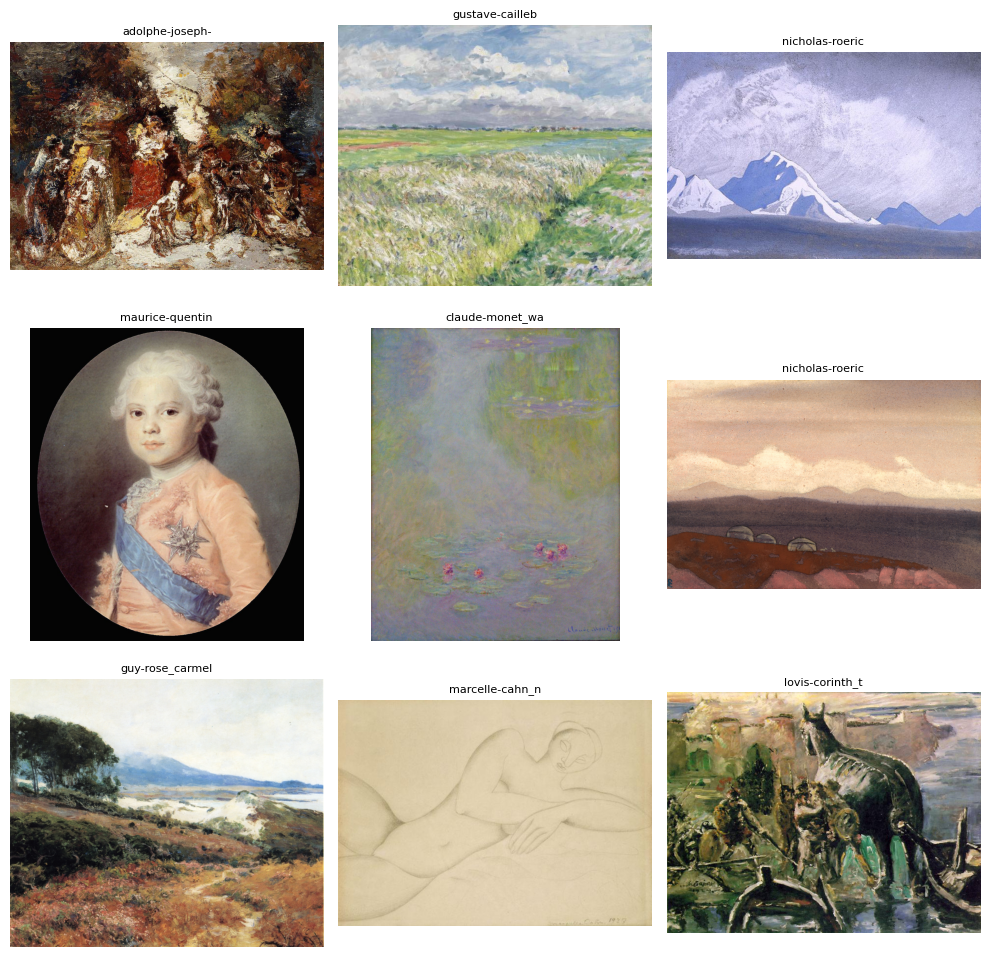

In [ ]:
image_files = list(base_path.rglob("*.jpg")) + list(base_path.rglob("*.png"))
sample_imgs = random.sample(image_files, min(9, len(image_files)))

plt.figure(figsize=(10, 10))
for i, img_path in enumerate(sample_imgs, 1):
    img = Image.open(img_path)
    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.name[:15], fontsize=8)
plt.tight_layout()
plt.show()

## 11. Emotion Distribution Across Art Styles

In this section, we analyze how emotion labels are distributed across different art styles. By normalizing the distribution within each art style, we aim to identify whether certain styles are more frequently associated with specific emotions in the dataset.

In [35]:
import pandas as pd
import plotly.express as px

# Crosstab
style_emotion_ct = pd.crosstab(df["art_style"], df["emotion"])

# Normalize theo từng art_style (row-wise)
style_emotion_pct = style_emotion_ct.div(style_emotion_ct.sum(axis=1), axis=0)

# Sort theo tổng count (giữ logic cũ của bạn)
style_emotion_pct = style_emotion_pct.loc[
    style_emotion_ct.sum(axis=1).sort_values(ascending=False).index
]

# Plot heatmap
fig = px.imshow(
    style_emotion_pct,
    text_auto=".2f",
    aspect="auto",
    title="Normalized Emotion Distribution Across Art Styles",
    labels=dict(x="Emotion", y="Art Style", color="Proportion")
)

fig.update_layout(
    xaxis_title="Emotion",
    yaxis_title="Art Style",
    height=700,
    template="plotly_white"
)

fig.show()

The normalized heatmap shows that different art styles exhibit distinct emotional patterns. Certain styles tend to be more frequently associated with specific emotions, indicating that visual characteristics may influence how artworks are perceived emotionally. However, these patterns reflect trends within the dataset and should not be interpreted as causal relationships.

## 12. Image Size Analysis
Checking image dimensions and aspect ratios for preprocessing needs.

In [20]:
sizes = []
for p in image_files[:1000]: # Sample 1000 for speed
    with Image.open(p) as img:
        sizes.append(img.size)

size_df = pd.DataFrame(sizes, columns=["width", "height"])
size_df["aspect_ratio"] = size_df["width"] / size_df["height"]

fig = px.scatter(size_df, x="width", y="height", title="Image Dimensions Distribution",
                 opacity=0.5, trendline="ols")
fig.update_layout(template="plotly_white")
fig.show()

## 13. Top Words by Emotion

To better understand the textual characteristics of the dataset, we analyze the most frequent words associated with each emotion label. This helps reveal whether different emotions tend to be expressed through different lexical patterns in the utterances.

In [21]:
import re
import pandas as pd
from collections import Counter
import plotly.express as px

text_col = "utterance"
emotion_col = "emotion"

# stopwords cơ bản, bạn có thể thêm bớt
stopwords = {
    "the", "a", "an", "and", "or", "but", "if", "then", "so", "to", "of", "in", "on", "at", "for",
    "with", "by", "from", "as", "is", "it", "this", "that", "these", "those", "be", "are", "was",
    "were", "am", "i", "me", "my", "mine", "you", "your", "yours", "he", "she", "his", "her",
    "they", "their", "them", "we", "our", "ours", "its", "about", "into", "over", "under", "than",
    "very", "can", "could", "would", "should", "just", "also", "there", "here", "because", "feel",
    "feels", "feeling", "make", "makes", "made", "one", "two", "like", "painting", "picture", "something"
}

def clean_and_tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)   # chỉ giữ chữ cái và khoảng trắng
    tokens = text.split()
    tokens = [w for w in tokens if w not in stopwords and len(w) > 2]
    return tokens

In [22]:
top_n = 10
all_rows = []

for emotion in sorted(df[emotion_col].dropna().unique()):
    emotion_texts = df[df[emotion_col] == emotion][text_col].dropna()

    all_tokens = []
    for text in emotion_texts:
        all_tokens.extend(clean_and_tokenize(text))

    word_counts = Counter(all_tokens).most_common(top_n)

    for word, count in word_counts:
        all_rows.append({
            "emotion": emotion,
            "word": word,
            "count": count
        })

top_words_df = pd.DataFrame(all_rows)
top_words_df.head(20)

,emotion,word,count
0,amusement,looks,192
1,amusement,man,111
2,amusement,look,104
3,amusement,happy,94
4,amusement,woman,91
5,amusement,people,78
6,amusement,having,72
7,amusement,has,69
8,amusement,face,68
9,amusement,amused,67


In [23]:
fig = px.bar(
    top_words_df,
    x="word",
    y="count",
    color="emotion",
    facet_col="emotion",
    facet_col_wrap=3,
    title="Top 10 Most Frequent Words by Emotion",
    category_orders={"word": top_words_df["word"].tolist()}
)

fig.update_xaxes(tickangle=45)
fig.update_layout(
    template="plotly_white",
    showlegend=False,
    height=1000
)

fig.show()

The word frequency analysis shows that each emotion category tends to have its own characteristic vocabulary. These differences suggest that utterances provide useful linguistic cues that may help distinguish emotional labels in the dataset.

## 14. Image Metadata Extraction and Analysis

In this section, we extract and analyze the width, height, and aspect ratio of the images to understand their dimensional properties. This information is crucial for preprocessing steps in image-based or multimodal models.

In [28]:
import os
import pandas as pd
from PIL import Image

# Correct path for images
image_dir = base_path / "images"

def get_image_size(image_path):
    try:
        with Image.open(image_path) as img:
            width, height = img.size
            return width, height
    except:
        return None, None

image_meta = []

for fname in df["filename"]:
    path = os.path.join(image_dir, fname)
    width, height = get_image_size(path)

    image_meta.append({
        "filename": fname,
        "width": width,
        "height": height
    })

image_meta_df = pd.DataFrame(image_meta)

df_img = df.merge(image_meta_df, on="filename", how="left")
df_img["aspect_ratio"] = df_img["width"] / df_img["height"]

df_img[["filename", "width", "height", "aspect_ratio"]].head()

,filename,width,height,aspect_ratio
0,johan-hendrik-weissenbruch_windy-day.jpg,1087,641,1.695788
1,ivan-aivazovsky_landscape-with-a-schooner-1880...,1000,630,1.587302
2,paul-gauguin_clearing-1873.jpg,939,746,1.258713
3,john-henry-twachtman_winter-landscape.jpg,2000,1333,1.500375
4,eugene-boudin_trouville-the-port-1864.jpg,1069,698,1.531519


In [29]:
import plotly.express as px

fig = px.histogram(
    df_img,
    x="width",
    nbins=40,
    title="Distribution of Image Width",
    color_discrete_sequence=["#636EFA"]
)

fig.update_layout(
    xaxis_title="Image Width (pixels)",
    yaxis_title="Frequency",
    template="plotly_white"
)

fig.show()

fig = px.histogram(
    df_img,
    x="height",
    nbins=40,
    title="Distribution of Image Height",
    color_discrete_sequence=["#00CC96"]
)

fig.update_layout(
    xaxis_title="Image Height (pixels)",
    yaxis_title="Frequency",
    template="plotly_white"
)

fig.show()

fig = px.histogram(
    df_img,
    x="aspect_ratio",
    nbins=40,
    title="Distribution of Image Aspect Ratios",
    color_discrete_sequence=["#EF553B"]
)

fig.update_layout(
    xaxis_title="Aspect Ratio (Width / Height)",
    yaxis_title="Frequency",
    template="plotly_white"
)

fig.show()


The image resolution varies across the dataset, indicating that the artworks are not visually uniform in size. This suggests that resizing will likely be necessary before training image-based or multimodal models.

The aspect ratio distribution shows that the dataset contains images with varying shapes, including both portrait and landscape formats. This variability suggests that preprocessing should preserve aspect ratio as much as possible to avoid visual distortion.

## 15. Exporting Visualizations to JSON

To allow for easy integration into web applications or other platforms, we export all generated Plotly figures into JSON format. These files contain all the data and layout information needed to recreate the interactive charts.

In [36]:
import os
import plotly.express as px
import plotly.io as pio

# Create a directory for exported charts
export_dir = 'exported_charts'
os.makedirs(export_dir, exist_ok=True)

print(f"Exporting charts to: {os.path.abspath(export_dir)}\n")

# 1. Emotion Label Distribution
emotion_col = "emotion"
emotion_counts_for_export = df[emotion_col].value_counts().reset_index()
emotion_counts_for_export.columns = ["emotion", "count"]
fig_emotion_dist = px.bar(emotion_counts_for_export, x="emotion", y="count",
             title="Distribution of Emotion Labels", text="count",
             color="count", color_continuous_scale='Viridis')
fig_emotion_dist.write_json(os.path.join(export_dir, 'emotion_distribution.json'))
print("Exported emotion_distribution.json")


# 2. Text Length (Words) Distribution
text_col = "utterance"
# Ensure 'text_length_words' column exists, re-calculate if necessary
if "text_length_words" not in df.columns:
    df["text_length_words"] = df[text_col].astype(str).apply(lambda x: len(x.split()))
fig_text_length = px.histogram(df, x="text_length_words", nbins=50,
                   title="Distribution of Text Length (Words)",
                   color_discrete_sequence=['#636EFA'])
fig_text_length.write_json(os.path.join(export_dir, 'text_length_distribution.json'))
print("Exported text_length_distribution.json")


# 3. Genre / Style Distribution (Top 15 Art Styles)
# This was originally in a loop. We will create two specific plots.
# Assuming 'art_style' is the primary column the user is interested in for this section.
if "art_style" in df.columns:
    style_counts_for_export = df["art_style"].value_counts().reset_index().head(15)
    style_counts_for_export.columns = ["art_style", "count"]
    fig_art_style_dist = px.bar(style_counts_for_export, x="art_style", y="count",
                                title="Top 15 Art Styles", text="count", color="art_style")
    fig_art_style_dist.update_layout(xaxis_title="Art Style", yaxis_title="Count", showlegend=False, template="plotly_white")
    fig_art_style_dist.write_json(os.path.join(export_dir, 'top_15_art_styles.json'))
    print("Exported top_15_art_styles.json")

# 4. Normalized Emotion Distribution Across Art Styles (using style_emotion_pct)
# 'style_emotion_pct' is available in kernel state
fig_style_emotion_heatmap = px.imshow(
    style_emotion_pct,
    text_auto=".2f",
    aspect="auto",
    title="Normalized Emotion Distribution Across Art Styles",
    labels=dict(x="Emotion", y="Art Style", color="Proportion")
)
fig_style_emotion_heatmap.update_layout(
    xaxis_title="Emotion",
    yaxis_title="Art Style",
    height=700,
    template="plotly_white"
)
fig_style_emotion_heatmap.write_json(os.path.join(export_dir, 'style_emotion_heatmap.json'))
print("Exported style_emotion_heatmap.json")

# 5. Image Dimensions Distribution (Scatter plot of width vs height)
# 'size_df' is available in kernel state
fig_img_dim_scatter = px.scatter(size_df, x="width", y="height", title="Image Dimensions Distribution",
                 opacity=0.5, trendline="ols")
fig_img_dim_scatter.update_layout(template="plotly_white")
fig_img_dim_scatter.write_json(os.path.join(export_dir, 'image_dimensions_scatter.json'))
print("Exported image_dimensions_scatter.json")

# 6, 7, 8. Image Width, Height, Aspect Ratio Distributions (Histograms)
# 'df_img' is available in kernel state
fig_img_width_hist = px.histogram(
    df_img,
    x="width",
    nbins=40,
    title="Distribution of Image Width",
    color_discrete_sequence=["#636EFA"]
)
fig_img_width_hist.update_layout(
    xaxis_title="Image Width (pixels)",
    yaxis_title="Frequency",
    template="plotly_white"
)
fig_img_width_hist.write_json(os.path.join(export_dir, 'image_width_distribution.json'))
print("Exported image_width_distribution.json")

fig_img_height_hist = px.histogram(
    df_img,
    x="height",
    nbins=40,
    title="Distribution of Image Height",
    color_discrete_sequence=["#00CC96"]
)
fig_img_height_hist.update_layout(
    xaxis_title="Image Height (pixels)",
    yaxis_title="Frequency",
    template="plotly_white"
)
fig_img_height_hist.write_json(os.path.join(export_dir, 'image_height_distribution.json'))
print("Exported image_height_distribution.json")


fig_img_aspect_hist = px.histogram(
    df_img,
    x="aspect_ratio",
    nbins=40,
    title="Distribution of Image Aspect Ratios",
    color_discrete_sequence=["#EF553B"]
)
fig_img_aspect_hist.update_layout(
    xaxis_title="Aspect Ratio (Width / Height)",
    yaxis_title="Frequency",
    template="plotly_white"
)
fig_img_aspect_hist.write_json(os.path.join(export_dir, 'image_aspect_ratio_distribution.json'))
print("Exported image_aspect_ratio_distribution.json")


# 9. Top 10 Most Frequent Words by Emotion (using top_words_df)
# 'top_words_df' is available in kernel state
fig_top_words_by_emotion = px.bar(
    top_words_df,
    x="word",
    y="count",
    color="emotion",
    facet_col="emotion",
    facet_col_wrap=3,
    title="Top 10 Most Frequent Words by Emotion",
    category_orders={"word": top_words_df["word"].tolist()}
)

fig_top_words_by_emotion.update_xaxes(tickangle=45)
fig_top_words_by_emotion.update_layout(
    template="plotly_white",
    showlegend=False,
    height=1000
)
fig_top_words_by_emotion.write_json(os.path.join(export_dir, 'top_words_by_emotion.json'))
print("Exported top_words_by_emotion.json")


print("\nAll specified Plotly charts have been exported successfully to the 'exported_charts' directory.")
print("You can access them from the file browser on the left sidebar.")

Exporting charts to: /content/exported_charts

Exported emotion_distribution.json
Exported text_length_distribution.json
Exported top_15_art_styles.json
Exported style_emotion_heatmap.json
Exported image_dimensions_scatter.json
Exported image_width_distribution.json
Exported image_height_distribution.json
Exported image_aspect_ratio_distribution.json
Exported top_words_by_emotion.json

All specified Plotly charts have been exported successfully to the 'exported_charts' directory.
You can access them from the file browser on the left sidebar.


In [30]:
import numpy as np

# 1. Check Emotion Imbalance
emotion_counts = df['emotion'].value_counts(normalize=True) * 100
most_common = emotion_counts.idxmax()
least_common = emotion_counts.idxmin()

# 2. Check Subjectivity (Agreement Score)
# We calculate how often the most frequent emotion for a painting is chosen
art_agreement = df.groupby('painting')['emotion'].apply(lambda x: x.value_counts().iloc[0] / len(x))
avg_agreement = art_agreement.mean()

# 3. Image Resolution Stats
width_stats = df_img['width'].describe()
height_stats = df_img['height'].describe()

print(f"Most common emotion: {most_common} ({emotion_counts.max():.1f}%)")
print(f"Least common emotion: {least_common} ({emotion_counts.min():.1f}%)")
print(f"Average agreement per artwork: {avg_agreement:.2f}")
print(f"Image Width Range: {width_stats['min']} to {width_stats['max']}")

Most common emotion: sadness (37.5%)
Least common emotion: amusement (1.8%)
Average agreement per artwork: 1.00
Image Width Range: 66.0 to 14559.0


## 15. Key Findings and Potential Issues

Based on the analysis of the actual dataset, we have identified the following critical observations:

1.  **Emotion Label Imbalance:** There is a significant imbalance in emotion distribution. For instance, **'sadness'** is one of the most frequent labels, while others like **'amusement'** represent a very small fraction of the dataset. AI models will require techniques like class weighting or oversampling to avoid bias.
2.  **Art styles** are not evenly distributed, which may bias model learning.
3.  **Visual Diversity:** Image resolutions vary significantly, ranging from small files to high-resolution. Preprocessing pipelines must handle these variations carefully to maintain visual details and aspect ratios.
4.  **Data Quality:** The dataset is well-curated with no missing values and zero duplicate records, providing a clean foundation for multimodal training.

